# WEEK 6: Cost Functions
### Chirag Rao KV 
### 240962180
### AIML B 16

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

In [59]:
data = {
    "salary": [1.7,2.4,2.3,3.1,3.7,4.2,4.4,6.1,5.4,5.7,6.4,6.2],
    "experience": [1.2,1.5,1.9,2.2,2.4,2.5,2.8,3.1,3.3,3.7,4.2,4.4]
}
data = pd.DataFrame(data)
x = np.array([1.7,2.4,2.3,3.1,3.7,4.2,4.4,6.1,5.4,5.7,6.4,6.2])
y = np.array( [1.2,1.5,1.9,2.2,2.4,2.5,2.8,3.1,3.3,3.7,4.2,4.4])

Text(0.5, 1.0, 'Slope vs mse')

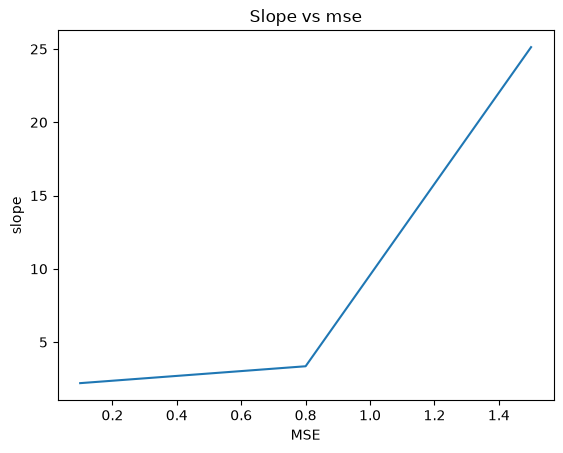

In [60]:
w =[0.1,0.8,1.5]
b = 1.1
mse = []
for i in range(len(w)):
    loss = (y - (w[i]*x+b))**2
    mse.append(np.mean(loss))
plt.plot(w,mse)
plt.xlabel("MSE")
plt.ylabel("slope")
plt.title("Slope vs mse")

Text(0.5, 1.0, 'Slope vs mse')

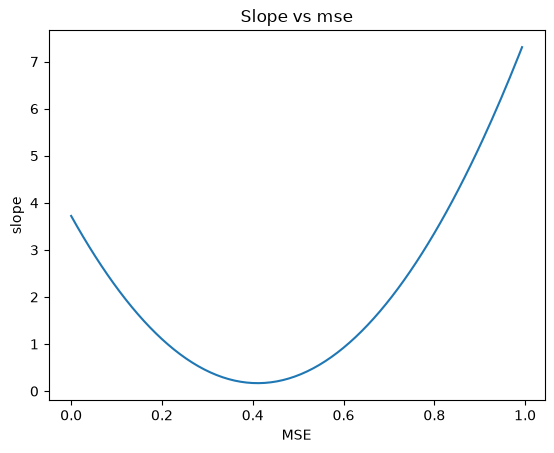

In [61]:
w=[]
for i in range(150):
    w.append(i/150)
b = 1.1
mse = []
for i in range(len(w)):
    loss = (y - (w[i]*x+b))**2
    mse.append(np.mean(loss))
plt.plot(w,mse)
plt.xlabel("MSE")
plt.ylabel("slope")
plt.title("Slope vs mse")

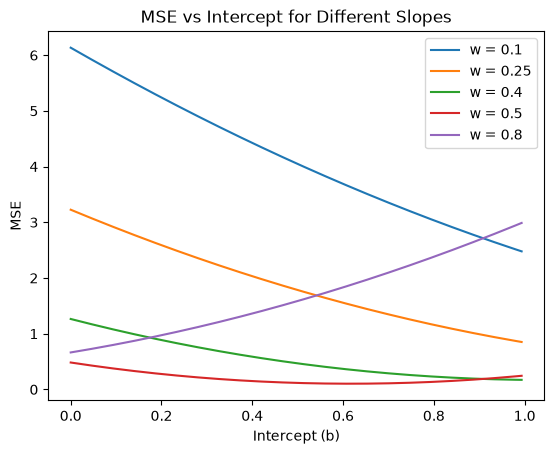

In [62]:
b = []
w = [0.1,0.25,0.4, 0.5,0.8]
for i in range(150):
    b.append(i/150)
for j in range(len(w)):
    mse = []  
    for i in range(len(b)):
        loss = (y - (w[j] * x + b[i])) ** 2
        mse.append(np.mean(loss))

    plt.plot(b, mse, label=f"w = {w[j]}")
plt.xlabel("Intercept (b)")
plt.ylabel("MSE")
plt.title("MSE vs Intercept for Different Slopes")
plt.legend()
plt.show()

In [63]:
from sklearn.metrics import mean_squared_error
w = 0.8
b = 0.5
y_pred = w * x + b
mse_manual = np.mean((y - y_pred) ** 2)
mse_sklearn = mean_squared_error(y, y_pred)
print("MSE using manual method:", mse_manual)
print("MSE using sklearn:", mse_sklearn)

MSE using manual method: 1.5870000000000006
MSE using sklearn: 1.5870000000000006


100%|██████████| 300/300 [00:00<00:00, 23397.01it/s]


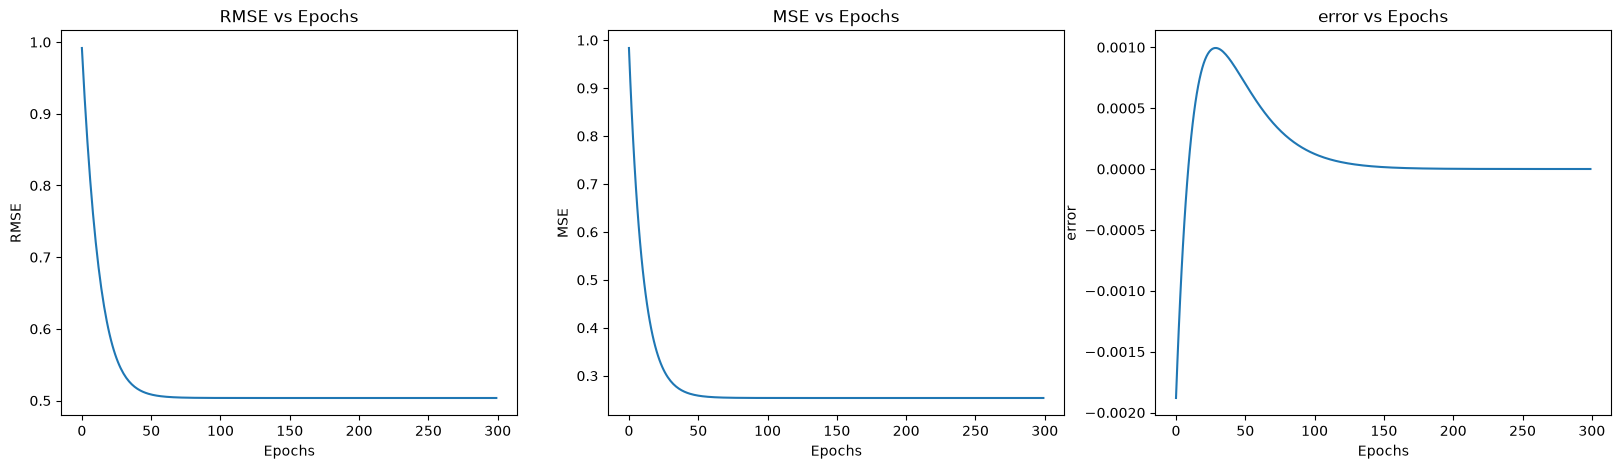

In [86]:
class Simple_LR:
    def __init__(self, x, y):
        self.x = np.asarray(x)
        self.y = np.asarray(y)

        if self.x.ndim == 1:
            self.x = self.x.reshape(-1, 1)

        self.weights = np.zeros(self.x.shape[1])
        self.bias = 0

    def predict(self,x):
        return x * self.weights + self.bias

    def train(self,no_epoch,alpha,norm_y=True):
        self.x = (self.x-np.mean(self.x,axis=0))/np.std(self.x,axis=0)
        if(norm_y):
            self.y = (self.y-np.mean(self.y))/np.std(self.y)
        self.rmse = []
        self.mean_error = []
        y_pred = np.zeros_like(self.y)
        loss_ = []
        self.w = []
        for i in tqdm(range(no_epoch)):
            epoch_error = []
            for j in range(len(self.x)):
                y_pred[j] = np.dot(self.x[j], self.weights) + self.bias
                error = self.y[j] - y_pred[j]
                dw = -self.x[j] * error
                db = -error
                self.weights = self.weights - alpha * dw
                
                self.bias = self.bias - alpha * db
                epoch_error.append(error)
            self.w.append(self.weights)
            self.rmse.append(np.sqrt(np.mean(np.array(epoch_error)**2)))
            self.mean_error.append(np.mean(np.array(epoch_error)**2))
            loss_.append(np.mean(epoch_error))
        
        fig, ax = plt.subplots(1, 3, figsize=(20, 5))
        ax[0].plot(self.rmse)
        ax[0].set_xlabel("Epochs")
        ax[0].set_ylabel("RMSE")
        ax[0].set_title("RMSE vs Epochs")
        ax[1].plot(self.mean_error)
        ax[1].set_xlabel("Epochs")
        ax[1].set_ylabel("MSE")
        ax[1].set_title("MSE vs Epochs")
        plt.plot(loss_)
        ax[2].set_xlabel("Epochs")
        ax[2].set_ylabel("error")
        ax[2].set_title("error vs Epochs")
        plt.show()
    def plot(self):
        plt.plot(self.w,self.mean_error)
        plt.xlabel("slope")
        plt.ylabel("mse")
LR = Simple_LR(x,y)
LR.train(300,0.01)
# LR.plot_data()|

In [87]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
x = x.reshape(-1, 1)
lr = LinearRegression()
lr.fit(x, y)
B0 = lr.intercept_
B1 = lr.coef_[0]
y_pred = lr.predict(x)
error = mean_squared_error(y, y_pred)
print("B0 (Intercept):", B0)
print("B1 (Slope):", B1)


B0 (Intercept): 1.3000000000000003
B1 (Slope): -0.30000000000000004


100%|██████████| 300/300 [00:00<00:00, 18200.76it/s]


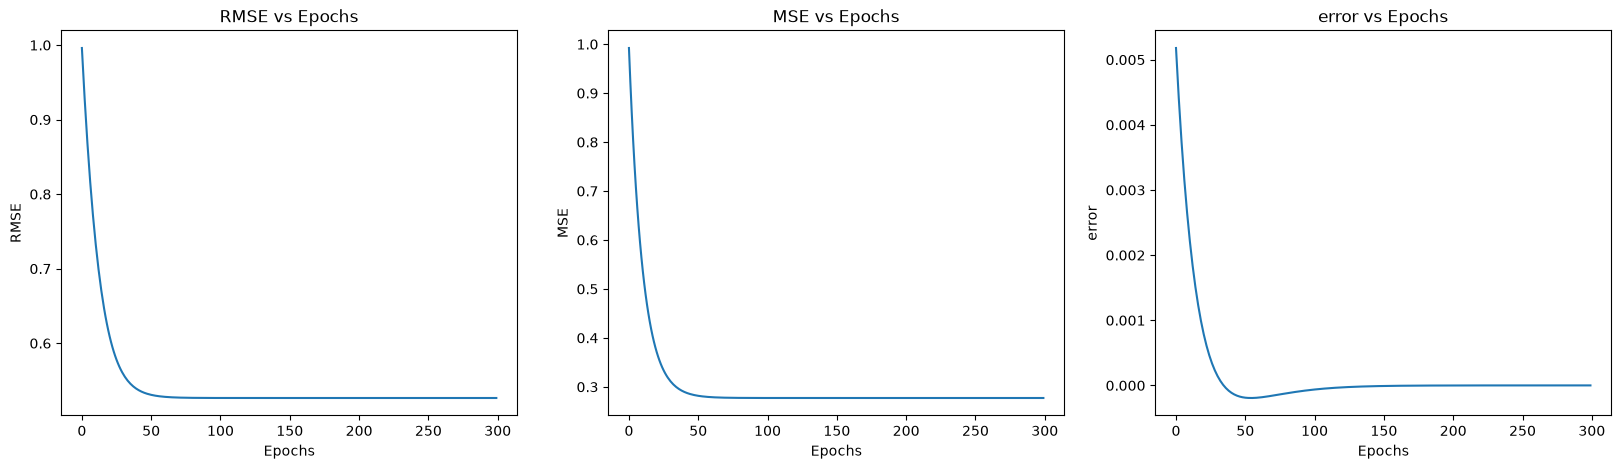

100%|██████████| 300/300 [00:00<00:00, 21770.50it/s]


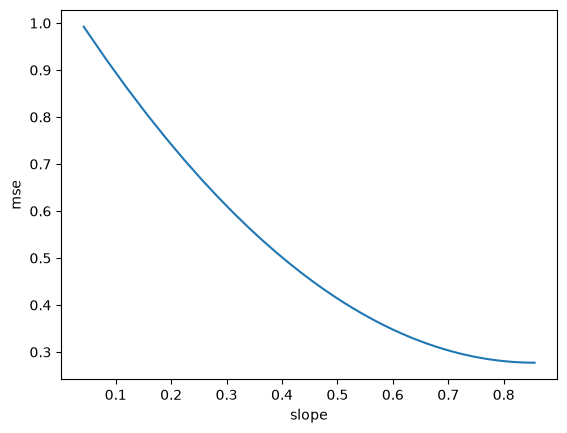

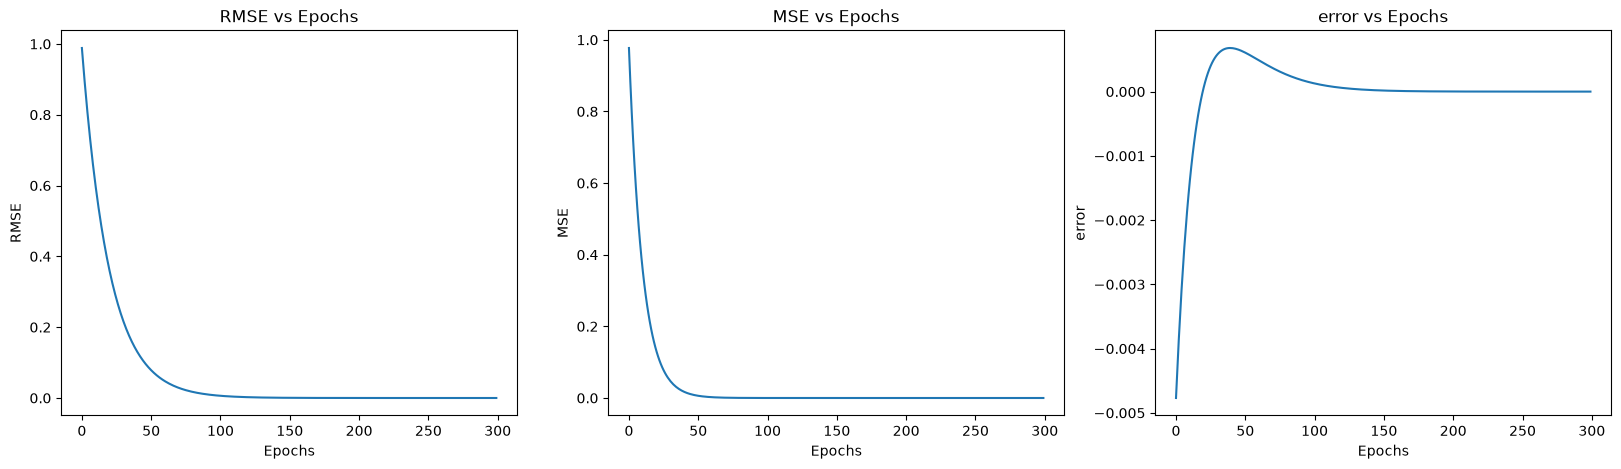

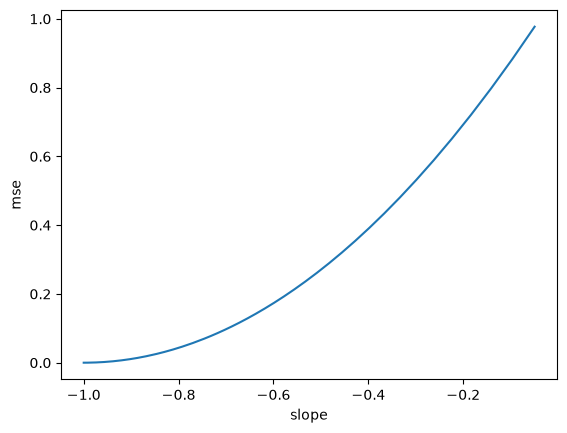

In [88]:
x = np.array([1, 2, 4, 3, 5])
y = np.array([1, 3, 3, 2, 5]) 
x1 = np.array([1, 2, 3, 4, 5])
y1 = np.array([10, 8, 6, 4, 2]) 
LR = Simple_LR(x,y)
LR.train(300,0.01)
LR.plot()
LR1 = Simple_LR(x1,y1)
LR1.train(300,0.01)
LR1.plot()

100%|██████████| 10/10 [00:00<00:00, 12818.78it/s]


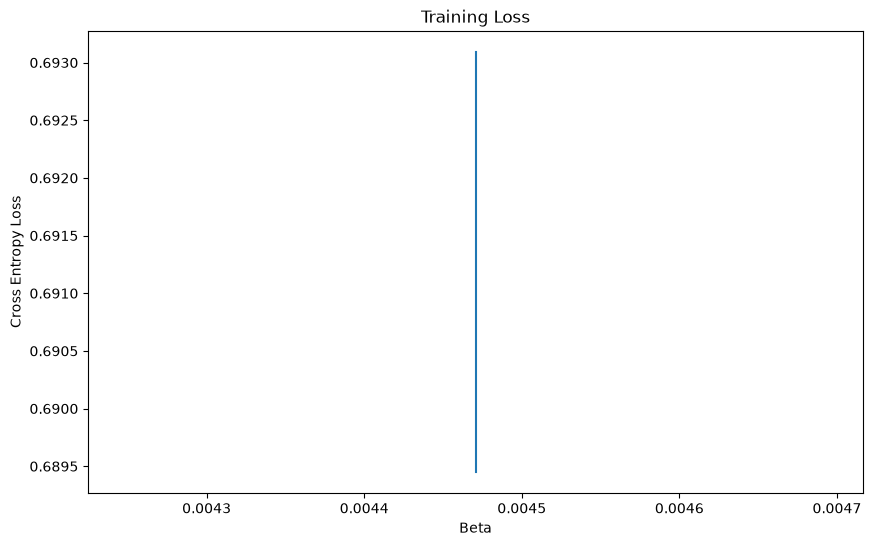

100%|██████████| 10/10 [00:00<00:00, 13967.05it/s]


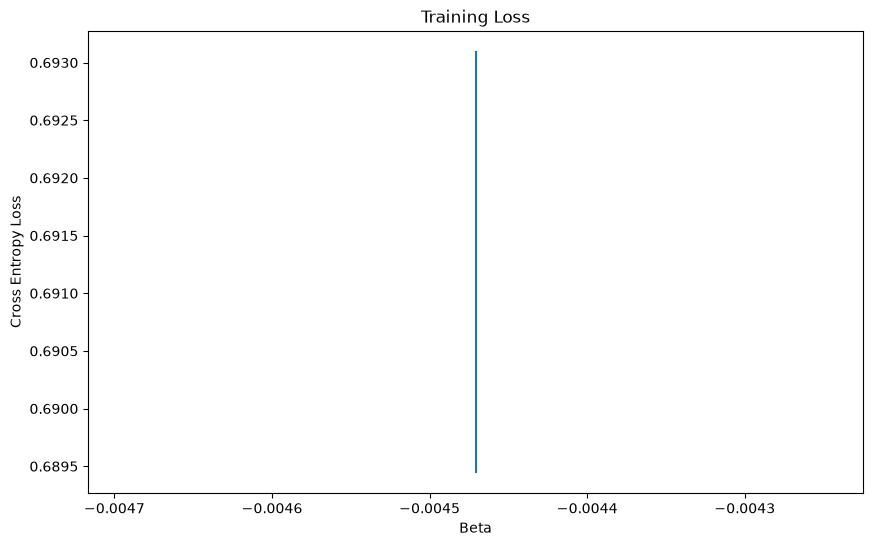

Method                        |weights         | bias            | cross entropy   
----------------------------------------------------------------------
positive slope                 | 0.004471        | 0.000492       | 0.689451       
negeive slope                  | -0.004471       | -0.000492      | 0.689451       


In [92]:
class LogiRegression:
    def __init__(self, x, y):
        self.x = np.asarray(x)
        self.y = np.asarray(y)
        if self.x.ndim == 1:
            self.x = self.x.reshape(-1, 1)
        self.weights = np.zeros(self.x.shape[1])
        self.bias = 0

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def cross_entropy_loss(self, pred, actual):
        epsilon = 1e-15
        pred = np.clip(pred, epsilon, 1 - epsilon)
        self.loss_ = -np.mean(actual * np.log(pred) +(1 - actual) * np.log(1 - pred))
        return self.loss_

    def predict(self, x):
        x = np.asarray(x)
        if x.ndim == 1:
            x = x.reshape(-1, 1)
        z = x @ self.weights + self.bias
        return self.sigmoid(z)

    def train(self, no_epoch, alpha):
        self.loss_train = []
        w = []
        for i in tqdm(range(no_epoch)):
            epoch_pred = []
            for j in range(len(self.x)):
                z = np.dot(self.x[j], self.weights) + self.bias
                y_pred = self.sigmoid(z)
                error = y_pred - self.y[j]
                dw = self.x[j] * error
                db = error
                self.weights -= alpha * dw
                self.bias -= alpha * db
                epoch_pred.append(y_pred)
            w.append(self.weights)
            epoch_pred = np.array(epoch_pred)
            loss = self.cross_entropy_loss(epoch_pred,self.y)
            self.loss_train.append(loss)

        plt.figure(figsize=(10, 6))

        plt.plot(w, self.loss_train)

        plt.xlabel("Beta")
        plt.ylabel("Cross Entropy Loss")
        plt.title("Training Loss")
        plt.show()
x = np.array([1, 2, 3, 4, 5])
y = np.array([0, 0, 1, 1, 1]) # Positive slope
LG = LogiRegression(x,y)
LG.train(10,0.0001)

x = np.array([1, 2, 3, 4, 5])
y = np.array([1, 1, 0, 0, 0]) # Negative slope
LG1 = LogiRegression(x,y)
LG1.train(10,0.0001)

print(f"{'Method':<30}|{'weights':<15} | {'bias':<15} | {'cross entropy':<15} ")
print("-" * 70)
print(f"{'positive slope':<30} | {LG.weights[0]:<15.6f} | {LG.bias:<15.6f}| {np.mean(LG.loss_train[-1]):<15.6f}")
print(f"{'negeive slope':<30} | {LG1.weights[0]:<15.6f} | {LG1.bias:<15.6f}| {np.mean(LG1.loss_train[-1]):<15.6f}")
